In [3]:
from astropy.io import fits
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import Angle
import astropy.units as u


In [4]:
data_folder = 'ADP_FLAMES_30Dor_30arcmin'

In [6]:
fits_path = data_folder + "/ADP.2019-01-31T23_53_46.264.fits"

with fits.open(fits_path) as hdul:
    spec = hdul[1].data
    hdr = hdul[0].header

    wave = spec["WAVE"][0]
    flux = spec["FLUX_REDUCED"][0]
    err  = spec["ERR_REDUCED"][0]
    snr  = spec["SNR_REDUCED"][0]



In [ ]:
hdr

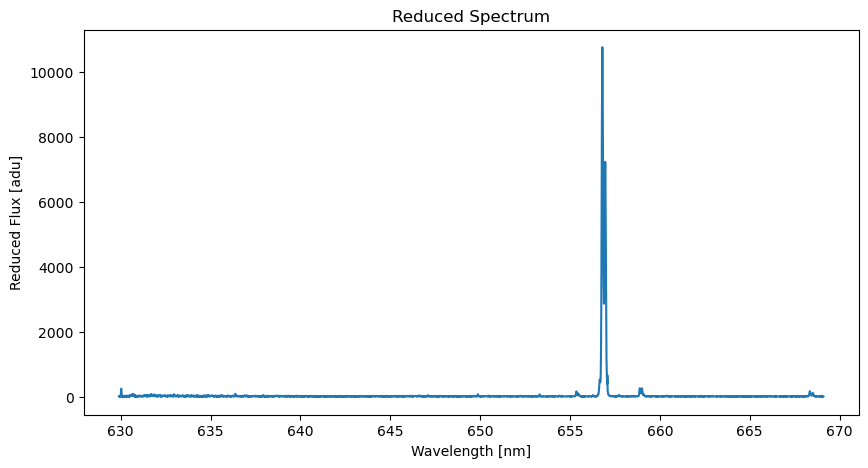

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(wave, flux)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Reduced Flux [adu]")
plt.title("Reduced Spectrum")
plt.show()

In [6]:
snr.max()

190.5401868904123

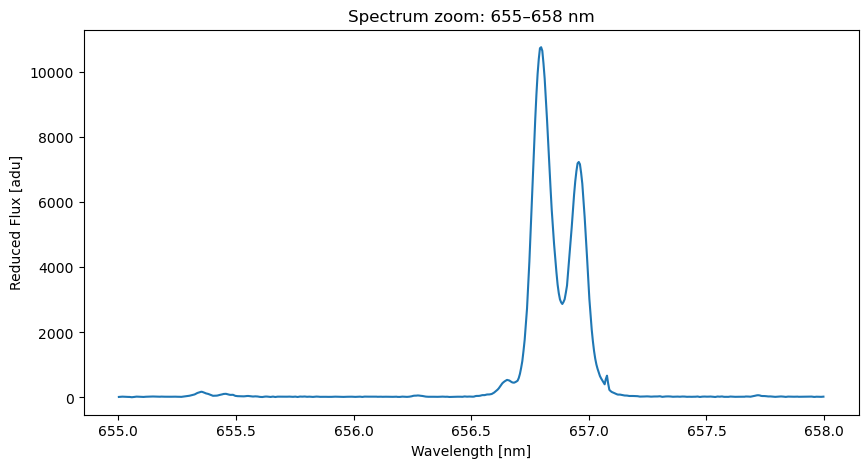

In [7]:

wmin = 655
wmax = 658

mask = (wave >= wmin) & (wave <= wmax)

plt.figure(figsize=(10, 5))
plt.plot(wave[mask], flux[mask])
plt.xlabel("Wavelength [nm]")
plt.ylabel("Reduced Flux [adu]")
plt.title(f"Spectrum zoom: {wmin}–{wmax} nm")
plt.show()

In [8]:
keys = [
    "OBJECT",
    "DATE-OBS",
    "MJD-OBS",
    "INSTRUME",
    "TELESCOP",
    "ORIGIN",
    "ARCFILE",
    "RA",
    "DEC",
    "HIERARCH ESO OBS PROG ID",
    "HIERARCH ESO DPR CATG",
    "HIERARCH ESO DPR TYPE",
    "HIERARCH ESO DPR TECH",
    "HIERARCH ESO PRO CATG",
    "HIERARCH ESO PRO TECH"
]

for k in keys:
    print(f"{k}: {hdr.get(k)}")

OBJECT: t48
DATE-OBS: 2003-12-03T02:19:40.767
MJD-OBS: 52976.09699962
INSTRUME: GIRAFFE
TELESCOP: ESO-VLT-U2
ORIGIN: ESO
ARCFILE: ADP.2019-09-04T13:34:26.413.fits
RA: 84.6594166666653
DEC: -69.1110833333322
HIERARCH ESO OBS PROG ID: 072.C-0348(A)
HIERARCH ESO DPR CATG: None
HIERARCH ESO DPR TYPE: None
HIERARCH ESO DPR TECH: None
HIERARCH ESO PRO CATG: SCIENCE_RBNSPEC_IDP
HIERARCH ESO PRO TECH: MOS


# Loading all files

In [19]:
# --------------------------
# Config
# --------------------------
 
fits_dir = Path(r"/Users/javier/FLAMES_30Dor") / data_folder
output_csv = fits_dir / "adp_positions.csv"


# --------------------------
# Helper functions
# --------------------------
def parse_ra_dec_from_header(hdr):
    """
    Try to extract RA/Dec from a FITS header.
    Returns (ra_deg, dec_deg) or (np.nan, np.nan) if not found.

    This first tries direct numeric values in RA/DEC.
    If those fail, it tries string-like sexagesimal forms.
    """
    ra = hdr.get("RA")
    dec = hdr.get("DEC")

    # Case 1: numeric RA/DEC already in degrees
    try:
        if ra is not None and dec is not None:
            ra_deg = float(ra)
            dec_deg = float(dec)
            return ra_deg, dec_deg
    except Exception:
        pass

    # Case 2: sexagesimal strings
    try:
        if ra is not None and dec is not None:
            ra_deg = Angle(str(ra), unit=u.hourangle).degree
            dec_deg = Angle(str(dec), unit=u.deg).degree
            return ra_deg, dec_deg
    except Exception:
        pass

    # Optional fallbacks if needed later
    # Add other header keywords here if some files miss RA/DEC
    return np.nan, np.nan


def read_basic_metadata(fits_path):
    """
    Read one FITS file and extract basic metadata.
    """
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header

    ra_deg, dec_deg = parse_ra_dec_from_header(hdr)

    row = {
        "filename": fits_path.name,
        "object": hdr.get("OBJECT"),
        "date_obs": hdr.get("DATE-OBS"),
        "mjd_obs": hdr.get("MJD-OBS"),  
        "instrument": hdr.get("INSTRUME"),
        "telescope": hdr.get("TELESCOP"),
        "arcfile": hdr.get("ARCFILE"),
        "prog_id": hdr.get("HIERARCH ESO OBS PROG ID"),
        "pro_catg": hdr.get("HIERARCH ESO PRO CATG"),
        "dpr_catg": hdr.get("HIERARCH ESO DPR CATG"),
        "dpr_type": hdr.get("HIERARCH ESO DPR TYPE"),
        "dpr_tech": hdr.get("HIERARCH ESO DPR TECH"),
        "ra_deg": ra_deg,
        "dec_deg": dec_deg,
    }
    return row


# --------------------------
# Load all FITS files
# --------------------------
fits_files = sorted(fits_dir.glob("*.fits"))

rows = []
bad_files = []

for f in fits_files:
    try:
        rows.append(read_basic_metadata(f))
    except Exception as e:
        bad_files.append((f.name, str(e)))

df = pd.DataFrame(rows)

# Save catalog
df.to_csv(output_csv, index=False)

print(f"Read {len(df)} FITS files")
print(f"Saved catalog to: {output_csv}")

if bad_files:
    print("\nFiles with issues:")
    for name, err in bad_files:
        print(f"  {name}: {err}")

print("\nFirst rows:")
print(df.head())

Read 4519 FITS files
Saved catalog to: /Users/javier/FLAMES_30Dor/ADP_FLAMES_30Dor_30arcmin/adp_positions.csv

First rows:
                           filename  object                 date_obs  \
0  ADP.2015-07-21T08_02_25.090.fits  pos098  2003-12-03T09:05:37.450   
1  ADP.2015-07-21T08_02_25.867.fits  pos103  2003-12-03T09:05:37.450   
2  ADP.2015-07-21T08_02_26.550.fits  pos082  2003-12-03T09:05:37.450   
3  ADP.2015-07-21T08_02_26.837.fits  pos045  2003-12-03T09:05:37.450   
4  ADP.2015-07-21T08_02_27.470.fits  pos006  2003-12-03T09:05:37.450   

        mjd_obs instrument   telescope                           arcfile  \
0  52976.378906    GIRAFFE  ESO-VLT-U2  ADP.2015-07-21T08:02:25.090.fits   
1  52976.378906    GIRAFFE  ESO-VLT-U2  ADP.2015-07-21T08:02:25.867.fits   
2  52976.378906    GIRAFFE  ESO-VLT-U2  ADP.2015-07-21T08:02:26.550.fits   
3  52976.378906    GIRAFFE  ESO-VLT-U2  ADP.2015-07-21T08:02:26.837.fits   
4  52976.378906    GIRAFFE  ESO-VLT-U2  ADP.2015-07-21T08:02:27.

In [20]:
# Keep only rows with valid coordinates
df_plot = df.dropna(subset=["ra_deg", "dec_deg"]).copy()


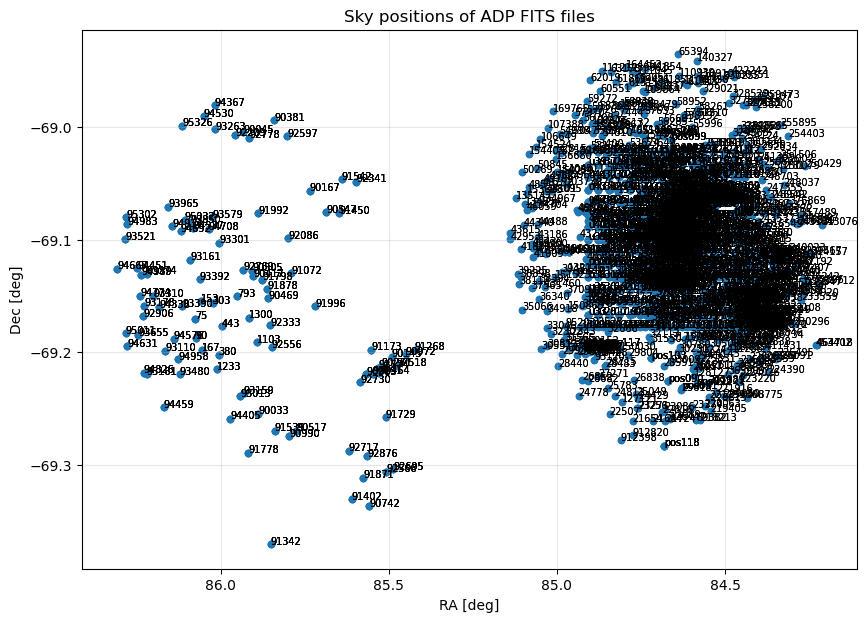

In [21]:

# Keep only rows with valid coordinates
df_plot = df.dropna(subset=["ra_deg", "dec_deg"]).copy()

plt.figure(figsize=(10, 7))
plt.scatter(df_plot["ra_deg"], df_plot["dec_deg"], s=20)

for _, row in df_plot.iterrows():
    plt.text(row["ra_deg"], row["dec_deg"], row["object"] or row["filename"], fontsize=7)

plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("Sky positions of ADP FITS files")
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [23]:
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

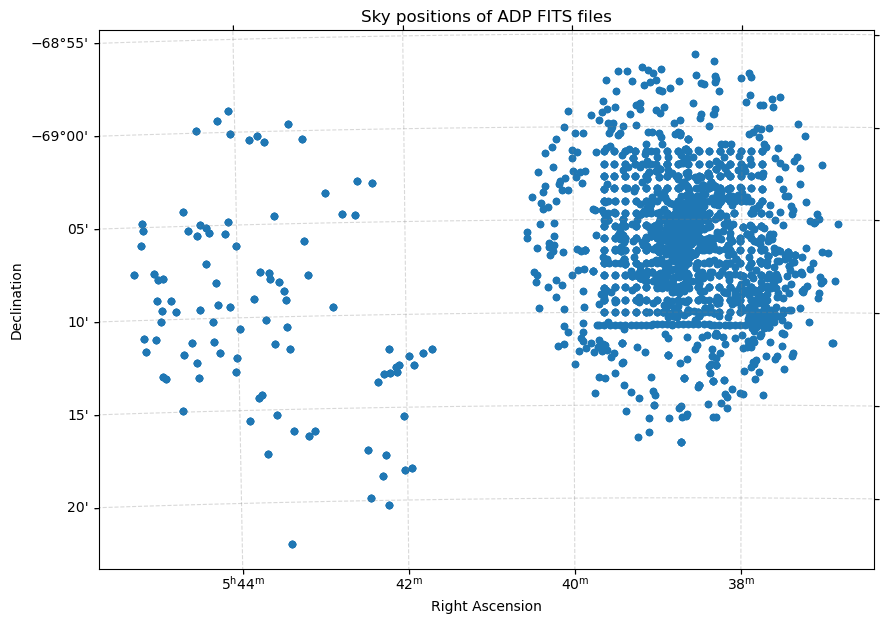

In [24]:

# Keep only rows with valid coordinates
df_plot = df.dropna(subset=["ra_deg", "dec_deg"]).copy()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1, projection=wcs)

ax.scatter(
    df_plot["ra_deg"],
    df_plot["dec_deg"],
    s=20,
    transform=ax.get_transform("world")
)

#for _, row in df_plot.iterrows():
#    label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
#    ax.text(
#        row["ra_deg"],
#        row["dec_deg"],
#        label,
#        fontsize=7,
#        transform=ax.get_transform("world")
#    )

ax.set_title("Sky positions of ADP FITS files")

ax.coords[0].set_axislabel("Right Ascension")
ax.coords[1].set_axislabel("Declination")
ax.grid(color="gray", alpha=0.3, linestyle="--")

plt.show()

In [25]:
df

,filename,object,date_obs,mjd_obs,instrument,telescope,arcfile,prog_id,pro_catg,dpr_catg,dpr_type,dpr_tech,ra_deg,dec_deg
0,ADP.2015-07-21T08_02_25.090.fits,pos098,2003-12-03T09:05:37.450,52976.378906,GIRAFFE,ESO-VLT-U2,ADP.2015-07-21T08:02:25.090.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.821958,-69.028556
1,ADP.2015-07-21T08_02_25.867.fits,pos103,2003-12-03T09:05:37.450,52976.378906,GIRAFFE,ESO-VLT-U2,ADP.2015-07-21T08:02:25.867.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.719625,-69.205111
2,ADP.2015-07-21T08_02_26.550.fits,pos082,2003-12-03T09:05:37.450,52976.378906,GIRAFFE,ESO-VLT-U2,ADP.2015-07-21T08:02:26.550.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.655292,-69.060250
3,ADP.2015-07-21T08_02_26.837.fits,pos045,2003-12-03T09:05:37.450,52976.378906,GIRAFFE,ESO-VLT-U2,ADP.2015-07-21T08:02:26.837.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.766708,-69.131056
4,ADP.2015-07-21T08_02_27.470.fits,pos006,2003-12-03T09:05:37.450,52976.378906,GIRAFFE,ESO-VLT-U2,ADP.2015-07-21T08:02:27.470.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.725042,-69.092389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4514,ADP.2019-09-04T13_34_27.424.fits,u40,2003-12-03T03:14:13.205,52976.134875,GIRAFFE,ESO-VLT-U2,ADP.2019-09-04T13:34:27.424.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.908583,-69.088861
4515,ADP.2019-09-04T13_34_27.426.fits,u15,2003-12-03T02:41:30.802,52976.112162,GIRAFFE,ESO-VLT-U2,ADP.2019-09-04T13:34:27.426.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.784000,-69.099972
4516,ADP.2019-09-04T13_34_27.428.fits,t44,2003-12-03T02:52:22.540,52976.119705,GIRAFFE,ESO-VLT-U2,ADP.2019-09-04T13:34:27.428.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.628250,-69.088861
4517,ADP.2019-09-04T13_34_27.430.fits,u25,2003-12-03T02:52:22.540,52976.119705,GIRAFFE,ESO-VLT-U2,ADP.2019-09-04T13:34:27.430.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.815125,-69.099972


In [27]:
from pathlib import Path
from astropy.io import fits

fits_files = sorted(fits_dir.glob("*.fits"))

spectra = []

for f in fits_files:
    try:
        with fits.open(f) as hdul:
            hdr = hdul[0].header
            tab = hdul[1].data

            wave = tab["WAVE"][0]
            flux = tab["FLUX_REDUCED"][0]
            err  = tab["ERR_REDUCED"][0]
           # snr  = tab["SNR"][0]

            spectra.append({
                "filename": f.name,
                "object": hdr.get("OBJECT"),
                "ra_deg": hdr.get("RA"),
                "dec_deg": hdr.get("DEC"),
                "wave": wave,
                "flux": flux,
                "err": err,
                "snr": snr,
            })

    except Exception as e:
        print(f"Could not read {f.name}: {e}")

print(f"Loaded {len(spectra)} spectra")

Loaded 4519 spectra


In [28]:
exptime_list = []

for fname in df["filename"]:
    fits_path = fits_dir / fname

    try:
        with fits.open(fits_path) as hdul:
            hdr = hdul[0].header
            exptime_list.append(hdr.get("EXPTIME", np.nan))
    except Exception as e:
        print(f"Could not read {fname}: {e}")
        exptime_list.append(np.nan)

df["EXPTIME"] = exptime_list

In [29]:
df["EXPTIME_round"] = df["EXPTIME"].round(1)

In [30]:
df["sample_id"] = (
    df["object"].astype(str).str.strip().str.lower()
    + "_ra" + df["ra_deg"].round(6).astype(str)
    + "_dec" + df["dec_deg"].round(6).astype(str)
    + "_exp" + df["EXPTIME_round"].astype(str)
)

In [31]:
import numpy as np
import pandas as pd

obj = df["object"].astype(str).str.strip().str.lower()

conditions = [
    obj.str.fullmatch(r"[a-z]\d{2}"),      # t10, u50
    obj.str.fullmatch(r"pos\d+"),          # pos082, pos07
    obj.str.fullmatch(r"\d+"),          # 7,58,123, 4567, etc.
]

choices = [
    "letter_two_digits",
    "pos_digits",
    "digits_only",
]

df["object_group"] = np.select(conditions, choices, default="other")

In [32]:
print(df["object_group"].value_counts())

object_group
digits_only          2396
letter_two_digits    1339
pos_digits            784
Name: count, dtype: int64


In [33]:
df_letter = df[df["object_group"] == "letter_two_digits"].copy()
df_pos    = df[df["object_group"] == "pos_digits"].copy()
df_num    = df[df["object_group"] == "digits_only"].copy()
#df_other  = df[df["object_group"] == "other"].copy()

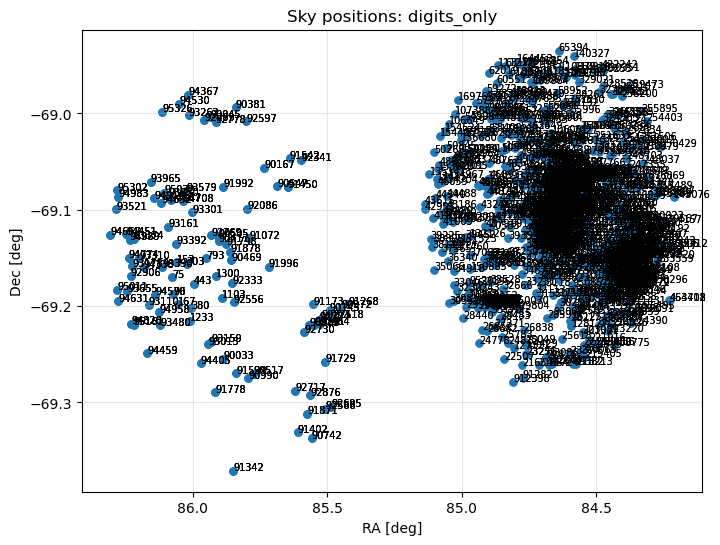

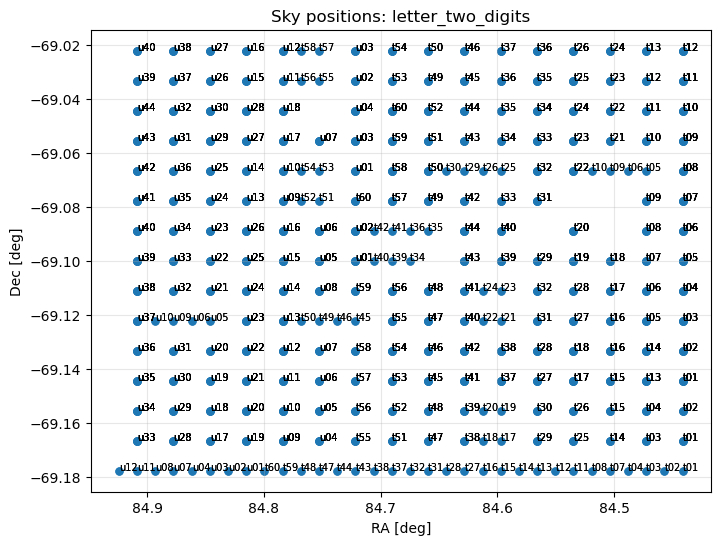

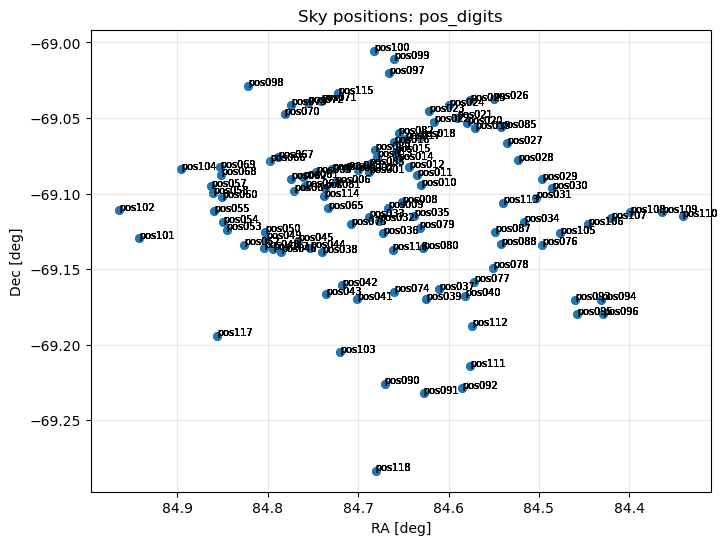

In [34]:
import matplotlib.pyplot as plt

groups = df.dropna(subset=["ra_deg", "dec_deg"]).groupby("object_group")

for group_name, subdf in groups:
    plt.figure(figsize=(8, 6))
    plt.scatter(subdf["ra_deg"], subdf["dec_deg"], s=25)

    for _, row in subdf.iterrows():
        label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
        plt.text(row["ra_deg"], row["dec_deg"], label, fontsize=7)

    plt.xlabel("RA [deg]")
    plt.ylabel("Dec [deg]")
    plt.title(f"Sky positions: {group_name}")
    plt.gca().invert_xaxis()
    plt.grid(True, alpha=0.3)
    plt.show()

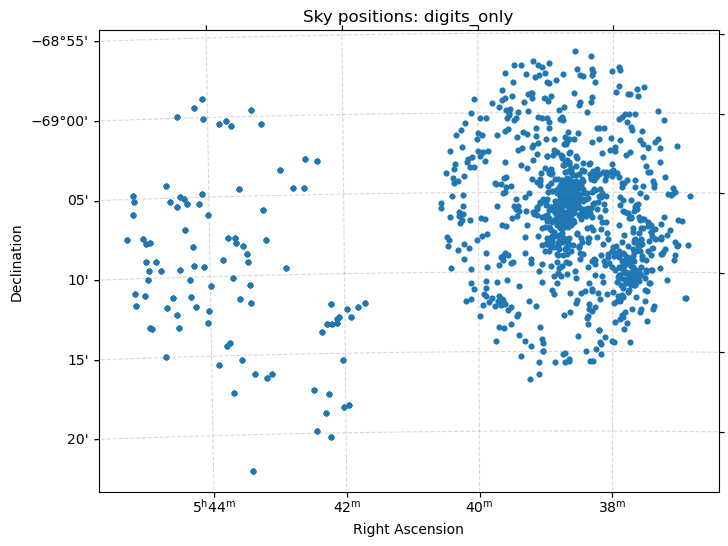

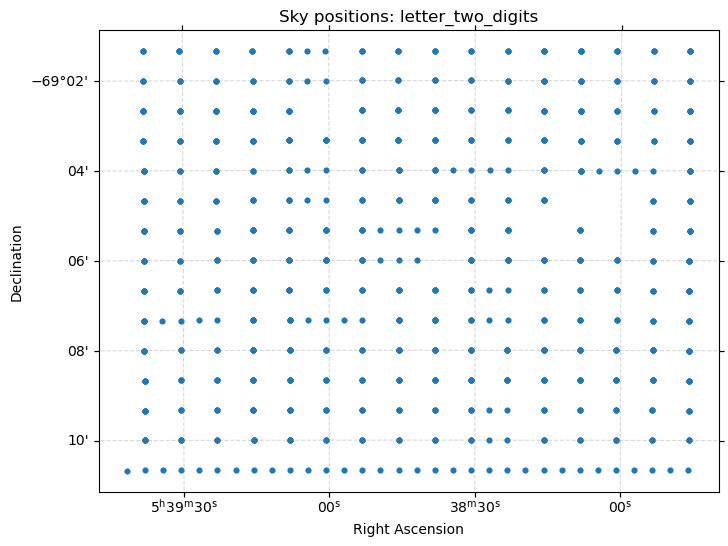

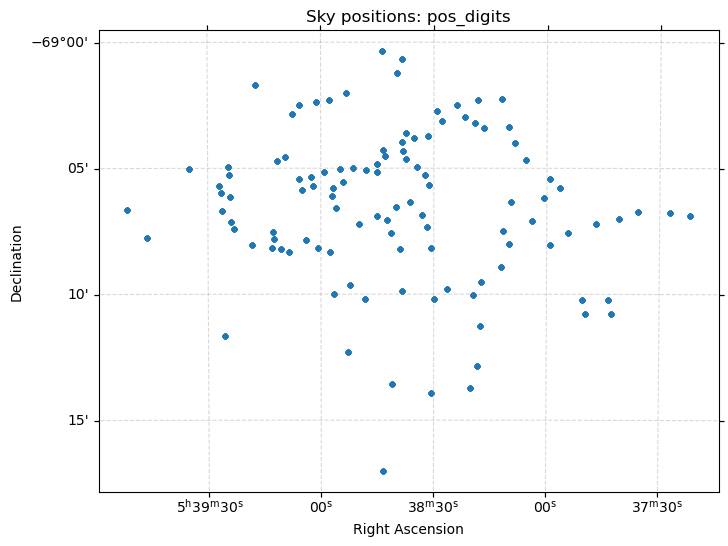

In [35]:
import matplotlib.pyplot as plt

groups = df.dropna(subset=["ra_deg", "dec_deg"]).groupby("object_group")

for group_name, subdf in groups:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(1, 1, 1, projection=wcs)

    ax.scatter(
        subdf["ra_deg"],
        subdf["dec_deg"],
        s=10,
        transform=ax.get_transform("world")
    )

#    for _, row in subdf.iterrows():
#        label = row["object"] if pd.notna(row["object"]) and row["object"] else row["filename"]
#        ax.text(
#            row["ra_deg"],
#            row["dec_deg"],
#            label,
#            fontsize=7,
#            transform=ax.get_transform("world")
#        )

    ax.set_title(f"Sky positions: {group_name}")
    ax.coords[0].set_axislabel("Right Ascension")
    ax.coords[1].set_axislabel("Declination")
    ax.grid(color="gray", alpha=0.3, linestyle="--")

    plt.show()

In [36]:
import pickle

# Output file
pickle_path = "flames30dor_dataframes.pkl"

# Store all dataframes in one dictionary
df_dict = {
    "df": df,
    "df_letter": df_letter,
    "df_pos": df_pos,
    "df_num": df_num,
}

# Save
with open(pickle_path, "wb") as f:
    pickle.dump(df_dict, f)

print(f"Saved pickle to:\n{pickle_path}")

Saved pickle to:
flames30dor_dataframes.pkl
